# 08 — Controller policy ladder and toy DP certificate (CTL-05 / CTL-06)

This notebook walks through the **controller milestone ladder** (CTL-05) and the **toy exact-DP optimality certificate** (CTL-06). The ladder compares ordering policies from a simple constant baseline up through corrected age-blind (Rung 0), damped survival-weighted (SW), rollout, and a frozen small-grid DP optimum. The certificate answers a narrower question: on a tractable instance, how far does a myopic base-stock policy sit below the true optimum?

Library modules (not notebook-only logic):

- `controller/rung0.py` — `CorrectedAgeBlindPolicy`
- `controller/toy_dp.py` — `solve_toy_dp`, `gap_vs_rollout`
- `sim/m2_ladder.py` — five-point harness (`constant` → `rung0` → `sw` → `rollout` → `dp`)
- `sim/m2_gates.py` — ENG-04 gates (β=1 degeneracy, DP certificate)

**Note (T-121):** Python closed-loop episode paths used by the full ladder harness were superseded by the Rust compute kernel (ADR 0127). `tests/test_damped_sw_policy.py` and `tests/test_m2_ladder.py` are module-skipped. Demos here use **policy order calls** and **toy DP** directly; the ladder bar chart is **conceptual** unless you have a tuned-alpha artifact and a working episode backend.

## Setup

Install the editable package with notebook + viz extras (`uv sync --extra notebooks --extra viz --python 3.11`). All demos import from `src/blueberries_voi/` — no notebook-only controller logic.

Policy **order** calls and **toy DP** run in pure Python. The full `run_m2_ladder` harness also needs closed-loop episode simulation and a T-029 tuned-α artifact; after T-121 Wave F those pytest modules are skipped, so the ladder bar chart below is **conceptual** unless you wire a working backend.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

from blueberries_voi.controller.rung0 import CorrectedAgeBlindPolicy
from blueberries_voi.controller.toy_dp import (
    DEMAND_SUPPORT,
    HORIZON,
    MAX_INVENTORY,
    MAX_LOTS,
    TAU_BINS,
    gap_vs_rollout,
    solve_toy_dp,
)
from blueberries_voi.filter.belief import ShelfBelief, effective_inventory
from blueberries_voi.model import ModelParams
from blueberries_voi.sim.bakeoff_damped_sw import (
    DampedSurvivalWeightedPolicy,
    protection_demand_quantile,
)
from blueberries_voi.sim.m2_gates import assert_beta1_degeneracy, assert_dp_certificate
from blueberries_voi.sim.m2_ladder import LADDER_POINTS
from blueberries_voi.sim.order_schedule import DEFAULT_ORDER_SCHEDULE

params = ModelParams()
schedule = DEFAULT_ORDER_SCHEDULE
order_days = [d for d in range(7) if schedule.can_order(d)]
print(f"Ladder points: {LADDER_POINTS}")
print(f"MWF order days (epoch week): {order_days}")

Ladder points: ('constant', 'rung0', 'sw', 'rollout', 'dp')
MWF order days (epoch week): [1, 3, 6]


## The five-point ladder (CTL-05)

`sim/m2_ladder.py` evaluates five arms under a **shared CRN root seed** and a **T-029 tuned-alpha table**:

| Point | Policy family | Role |
|-------|---------------|------|
| `constant` | `ConstantOrderPolicy` | Simple daily baseline |
| `rung0` | `CorrectedAgeBlindPolicy` | Nahmias-style age-blind competitor |
| `sw` | `DampedSurvivalWeightedPolicy` | Age-aware effective inventory (ρ=0.8 default) |
| `rollout` | `RolloutPolicy` over damped SW | One-step lookahead scoring |
| `dp` | `solve_toy_dp` optimum value | CTL-06 certificate arm (not episode profit) |

Orders follow the default **MWF schedule** (Sun / Tue / Thu) with day-indexed protection lengths 3 / 3 / 4 (CAL-01 / ADR 0112), not the legacy daily R+L=2 scalar alone.

In [2]:
print("Day-indexed protection on MWF order days:")
for d in order_days:
    print(f"  day {d}: protection_days={schedule.protection_days(d)}")

Day-indexed protection on MWF order days:
  day 1: protection_days=3
  day 3: protection_days=4
  day 6: protection_days=3


### ⚠️ WARNING — ladder `dp` arm vs episode profit

The **`dp` ladder point is not comparable** to the other four arms on **episode dollar profit**. `_evaluate_dp_profit()` in `m2_ladder.py` returns `J*(s₀)` from `solve_toy_dp` — a **toy reward scale** (unit revenue 1, holding 0.1, waste 1, stockout 5) on a **frozen tiny grid** (demand {0,1,2}, horizon 3, max inventory 4). The `constant` / `rung0` / `sw` / `rollout` arms score **closed-loop episode profit** on Abdella shipments with `ProfitCosts`.

Use the DP arm as an **optimality certificate anchor**, not a fifth bar on a single profit axis without rescaling.

## Rung 0 — corrected age-blind baseline

`CorrectedAgeBlindPolicy` observes **total on-hand only** (not lot ages) plus the order pipeline, applies a mean-survival outdating correction, then a damped base-stock order:

$$I^{R0} = \bar{w}(\mathrm{day}) \cdot N + \sum_j q_j \, w_{\mathrm{pipe}},\quad q = \mathrm{case\_round}\big(\rho [d^\star - I^{R0}]^+\big)$$

This is the **honest age-blind competitor**: it does not peek at ages, but it does not pretend every unit on the shelf is equally likely to sell before spoiling.

In [3]:
CASE_SIZE = 8
BAR_W = 0.75
PIPE_W = 0.75
DEMAND_TARGET = 64.0  # injected F^{-1} until demand helpers lock
RHO = 1.0

params = ModelParams(case_size=CASE_SIZE)
schedule = DEFAULT_ORDER_SCHEDULE


def make_belief(lot_counts: list[float], age_index: int = 0) -> ShelfBelief:
    grid = [0.0, 1.0, 2.0, 3.0, 4.0]
    margs = []
    for _ in lot_counts:
        row = [0.0] * len(grid)
        row[age_index % len(grid)] = 1.0
        margs.append(row)
    return ShelfBelief(lot_counts=[float(x) for x in lot_counts], age_marginals=margs, tau_grid=grid)


fixtures = [
    ([40.0], {}, "N=40, no pipeline"),
    ([40.0], {1: 16}, "N=40 + pending 16"),
    ([], {}, "empty shelf"),
    ([100.0], {}, "overstocked"),
]

day = 6  # Sunday — first MWF order day in week containing 2024-01-01
prot = schedule.protection_days(day)
rung0 = CorrectedAgeBlindPolicy(
    alpha=0.9,
    params=params,
    rho=RHO,
    mean_survival_weight=BAR_W,
    pipeline_weight=PIPE_W,
    demand_target=DEMAND_TARGET,
    protection_days=prot,
    case_size=CASE_SIZE,
    schedule=schedule,
)

print(f"Rung 0 on order day {day} (protection_days={prot})")
for lots, pending, label in fixtures:
    belief = make_belief(lots) if lots else ShelfBelief(lot_counts=[], age_marginals=[], tau_grid=[0.0, 1.0])
    q = rung0.order(day, belief, pending_orders=pending)
    total = sum(lots)
    inv = BAR_W * total + sum(float(v) * PIPE_W for v in pending.values())
    print(f"  {label:22s}  N={total:5.0f}  I^R0={inv:5.1f}  q={q}")

Rung 0 on order day 6 (protection_days=3)
  N=40, no pipeline       N=   40  I^R0= 30.0  q=32
  N=40 + pending 16       N=   40  I^R0= 42.0  q=24
  empty shelf             N=    0  I^R0=  0.0  q=64
  overstocked             N=  100  I^R0= 75.0  q=0


## Damped survival-weighted policy (ladder `sw` arm)

`DampedSurvivalWeightedPolicy` (`sim/bakeoff_damped_sw.py`) uses **age-aware** `effective_inventory` on `ShelfBelief` marginals:

$$q_t = \mathrm{case\_round}\big(\rho [F^{-1}_{D_{t:t+L}}(\alpha) - \tilde{I}_t]^+\big)$$

Default ρ=0.8 (Rung 0 defaults to ρ=1). **T-121 note:** `tests/test_damped_sw_policy.py` is module-skipped because Python policy dispatch moved to Rust; the class remains importable for order-table demos.

In [4]:
ALPHA = 0.9
sw = DampedSurvivalWeightedPolicy(alpha=ALPHA, params=params, rho=0.8, schedule=schedule)

print("Damped SW (ρ=0.8) vs Rung 0 (ρ=1) on same fixtures:")
for lots, pending, label in fixtures:
    belief = make_belief(lots) if lots else ShelfBelief(lot_counts=[], age_marginals=[], tau_grid=[0.0, 1.0])
    q_sw = sw.order(belief, day=day, pending_orders=pending)
    q_r0 = rung0.order(day, belief, pending_orders=pending)
    i_tilde = effective_inventory(belief, pending_orders=pending, params=params)
    print(f"  {label:22s}  Ĩ={i_tilde:5.1f}  SW={q_sw}  Rung0={q_r0}")

Damped SW (ρ=0.8) vs Rung 0 (ρ=1) on same fixtures:
  N=40, no pipeline       Ĩ= 40.0  SW=56  Rung0=32
  N=40 + pending 16       Ĩ= 55.5  SW=40  Rung0=24
  empty shelf             Ĩ=  0.0  SW=88  Rung0=64
  overstocked             Ĩ=100.0  SW=8  Rung0=0


## CTL-06 toy DP certificate

`solve_toy_dp()` runs backward induction on a **frozen small instance**:

- Demand support `{0, 1, 2}` (uniform)
- τ bins `(0, 1, 2, 3)` — truncated age grid
- `max_lots=2`, `max_inventory=4`, `horizon=3` order-day epochs
- Lead time 1 (one-period pipeline lag)
- Default schedule: MWF order days with schedule-aware protection

Returns optimal value/policy tables plus a **base (myopic protection) value table** for comparison.

### ⚠️ WARNING — `gap_vs_rollout` is not vs rollout (yet)

Despite the name, `gap_vs_rollout(result)` reports **$J^* - J_{\mathrm{base}}$** on the toy instance, where $J_{\mathrm{base}}$ is the **myopic protection base-stock** policy evaluated under the same dynamics — **not** `RolloutPolicy` from `sim/bakeoff_rollout.py`. When T-030 one-step rollout is wired as the comparison arm, the DP side stays fixed; only the base policy swaps.

Do not read this gap as "rollout improvement over SW" on the full episode ladder.

In [5]:
print("Frozen toy grid:")
print(f"  demand_support={DEMAND_SUPPORT}")
print(f"  tau_bins={TAU_BINS}")
print(f"  max_lots={MAX_LOTS}, max_inventory={MAX_INVENTORY}, horizon={HORIZON}")

toy = solve_toy_dp(schedule=DEFAULT_ORDER_SCHEDULE)
gap = gap_vs_rollout(toy)
s0 = toy.initial_state
j_star = toy.value_table[(0, s0)]
j_base = toy.base_value_table[(0, s0)]

print(f"\nInitial state: inventory={s0[0]}, pipeline={s0[1]}")
print(f"  J* (DP optimum)     = {j_star:.4f}")
print(f"  J_base (myopic)     = {j_base:.4f}")
print(f"  gap_vs_rollout      = {gap:.4f}")
print(f"  optimal order q*    = {toy.policy_table[(0, s0)]}")
print(f"  state space size    = {len(toy.value_table)} (t × states)")

Frozen toy grid:
  demand_support=(0, 1, 2)
  tau_bins=(0.0, 1.0, 2.0, 3.0)
  max_lots=2, max_inventory=4, horizon=3

Initial state: inventory=(0, 0, 0, 0), pipeline=0
  J* (DP optimum)     = -9.1000
  J_base (myopic)     = -9.2000
  gap_vs_rollout      = 0.1000
  optimal order q*    = 2
  state space size    = 1060 (t × states)


## ENG-04 M2 gates (`sim/m2_gates.py`)

Two gates exercised here:

1. **β=1 degeneracy** — when survival weight `w` is flat across lots (same-age fixture), Rung 0 and damped SW must agree on every MWF order day.
2. **DP certificate** — `gap_vs_rollout ≥ 0` on the schedule-aware toy instance.

In [6]:
beta_gate = assert_beta1_degeneracy()
dp_gate = assert_dp_certificate()

print("β=1 degeneracy gate:", beta_gate.ok, beta_gate.status)
print("DP certificate gate:", dp_gate.ok, dp_gate.status, f"gap={dp_gate.gap_vs_rollout}")

β=1 degeneracy gate: True ok
DP certificate gate: True ok gap=0.10000000000000142


### β=1 check — explicit order-day table

Reproduce the gate fixture: all lots Dirac on the same τ bin so `effective_inventory` collapses to a flat `w × N` correction.

In [7]:
from blueberries_voi.sim.m2_gates import _same_age_belief  # gate fixture helper

bar_w, pipe_w = 0.75, 0.75  # illustrative; gate computes from effective_inventory
unit = _same_age_belief(lot_counts=[1.0])
empty = _same_age_belief(lot_counts=[0.0])
bar_w = float(effective_inventory(unit, pending_orders={}, params=params))
pipe_w = float(effective_inventory(empty, pending_orders={1: 1}, params=params))
weights_by_weekday = {wd: bar_w for wd in range(7)}

sw_flat = DampedSurvivalWeightedPolicy(alpha=ALPHA, params=params, rho=1.0, schedule=schedule)

cases = [
    ([40.0], {}),
    ([10.0, 15.0, 15.0], {1: 16}),
    ([8.0, 8.0], {1: 8, 2: 8}),
    ([0.0], {}),
]

rows = []
for order_day in order_days:
    prot = schedule.protection_days(order_day)
    d_star = protection_demand_quantile(ALPHA, params, protection_days=prot)
    blind = CorrectedAgeBlindPolicy(
        alpha=ALPHA,
        params=params,
        rho=1.0,
        mean_survival_weight=weights_by_weekday,
        pipeline_weight=pipe_w,
        demand_target=d_star,
        protection_days=prot,
        case_size=CASE_SIZE,
        schedule=schedule,
    )
    for lots, pending in cases:
        belief = _same_age_belief(lot_counts=[float(x) for x in lots])
        q_blind = blind.order(order_day, belief, pending_orders=pending)
        q_sw = sw_flat.order(belief, day=order_day, pending_orders=pending)
        match = "✓" if q_blind == q_sw else "✗"
        rows.append((order_day, prot, sum(lots), q_blind, q_sw, match))

print(f"Flat-w weights: bar_w={bar_w:.4f}, pipe_w={pipe_w:.4f}")
print(f"{'day':>4} {'prot':>4} {'N':>5} {'blind':>5} {'SW':>5} match")
for row in rows:
    print(f"{row[0]:4d} {row[1]:4d} {row[2]:5.0f} {row[3]:5d} {row[4]:5d}   {row[5]}")

Flat-w weights: bar_w=1.0000, pipe_w=0.9703
 day prot     N blind    SW match
   1    3    40    64    64   ✓
   1    3    40    48    48   ✓
   1    3    16    72    72   ✓
   1    3     0   104   104   ✓
   3    4    40   104   104   ✓
   3    4    40    88    88   ✓
   3    4    16   112   112   ✓
   3    4     0   144   144   ✓
   6    3    40    64    64   ✓
   6    3    40    48    48   ✓
   6    3    16    72    72   ✓
   6    3     0   104   104   ✓


## Figures

Three plots:

1. **Ladder concept** — illustrative profit ordering (not from a live `run_m2_ladder` run)
2. **Toy DP state space** — optimal value $V_0(s)$ over inventory × pipeline at $t=0$
3. **β=1 check** — all order-day comparisons must lie on the diagonal

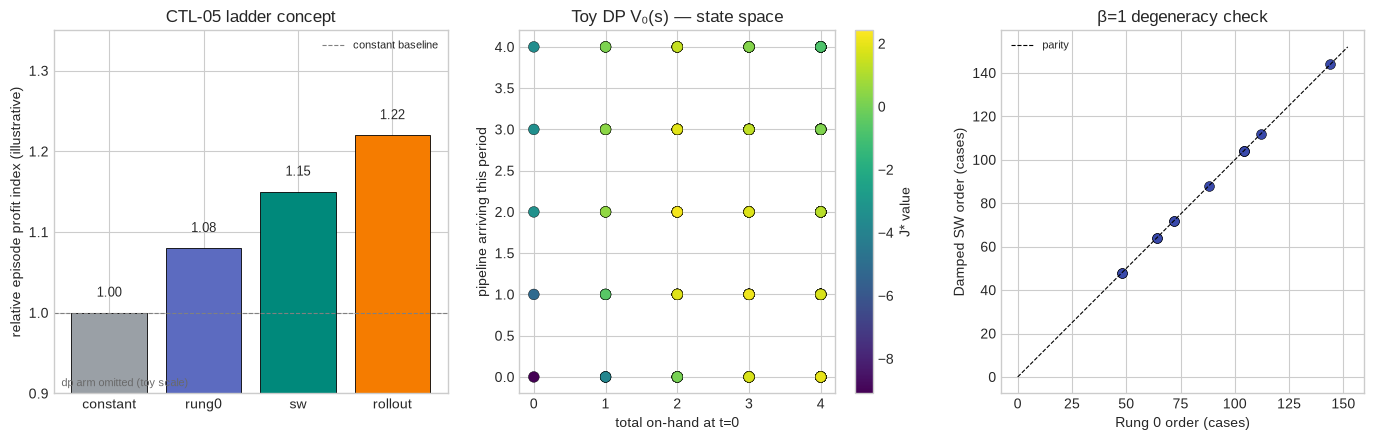

In [8]:
# --- 1. Ladder bar chart (conceptual) ---
# Illustrative episode-profit indices from milestone narrative; dp arm omitted
# (toy J* is on a different reward scale — see WARNING above).
concept_labels = ["constant", "rung0", "sw", "rollout"]
concept_profit_index = np.array([1.0, 1.08, 1.15, 1.22])  # relative, not dollars

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
colors = ["#9aa0a6", "#5c6bc0", "#00897b", "#f57c00"]
bars = ax.bar(concept_labels, concept_profit_index, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="constant baseline")
ax.set_ylabel("relative episode profit index (illustrative)")
ax.set_title("CTL-05 ladder concept")
ax.set_ylim(0.9, 1.35)
ax.legend(fontsize=8)
for b, v in zip(bars, concept_profit_index):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
ax.text(0.02, 0.02, "dp arm omitted (toy scale)", transform=ax.transAxes, fontsize=8, color="dimgray")

# --- 2. Toy DP value surface at t=0 ---
ax = axes[1]
inv_totals = []
pipe_vals = []
v_vals = []
for key, val in toy.value_table.items():
    t, (inv, pipe) = key
    if t != 0:
        continue
    inv_totals.append(sum(inv))
    pipe_vals.append(pipe)
    v_vals.append(val)

sc = ax.scatter(inv_totals, pipe_vals, c=v_vals, cmap="viridis", s=60, edgecolors="k", linewidths=0.3)
ax.set_xlabel("total on-hand at t=0")
ax.set_ylabel("pipeline arriving this period")
ax.set_title("Toy DP V₀(s) — state space")
plt.colorbar(sc, ax=ax, label="J* value")

# --- 3. β=1 parity scatter ---
ax = axes[2]
q_blind_list = [r[3] for r in rows]
q_sw_list = [r[4] for r in rows]
ax.scatter(q_blind_list, q_sw_list, c="#3949ab", s=50, edgecolors="k", linewidths=0.4)
lim = max(max(q_blind_list), max(q_sw_list)) + 8
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="parity")
ax.set_xlabel("Rung 0 order (cases)")
ax.set_ylabel("Damped SW order (cases)")
ax.set_title("β=1 degeneracy check")
ax.legend(fontsize=8)
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()

## Running the full ladder harness

To produce real numeric artifacts (not the conceptual chart above):

```python
from pathlib import Path
from blueberries_voi.sim.m2_ladder import run_m2_ladder

result = run_m2_ladder(
    alpha_table_path=Path("experiments/tuned_alpha.json"),
    root_seed=42,
)
print(result.profits)
```

Requires a complete **T-029 tuned-alpha table** and a working **closed-loop episode backend**. After T-121 Wave F, Python episode simulation paths may be unavailable; prefer the Rust session backend for production runs. `tests/test_m2_ladder.py` remains skipped until that integration is restored for the harness.

## Summary

- **Ladder** (`m2_ladder.py`): five policy families under shared seed + tuned α; `dp` is toy optimum value, not episode profit.
- **Rung 0** (`rung0.py`): total on-hand + pipeline with mean-survival correction; fair age-blind baseline.
- **Toy DP** (`toy_dp.py`): exact certificate on a frozen grid; `gap_vs_rollout` = optimum minus **myopic base-stock**, not rollout.
- **Gates** (`m2_gates.py`): β=1 flat-`w` degeneracy and non-negative DP gap — both pass on the default MWF schedule.
- **T-121**: Python damped-SW / ladder pytest modules skipped; demos use direct policy + toy DP calls.